In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/Unemployment in India (3).csv')

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
print(df.shape)

print(df.info())

print(df.describe())

(768, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
None
       Estimated Unemployment Rate (%)  Estimated Employed  \
count                       740.000000        7.400000e+02   
mean                         11.787946        7.204460e+06   
std 

In [ ]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [ ]:
df.dropna(inplace=True)

df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0


In [ ]:
print(df.head())

# Average unemployment rate
print("Average Unemployment Rate:")
print(df['Estimated Unemployment Rate (%)'].mean())

           Region         Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019   Monthly                             3.65   
1  Andhra Pradesh   30-06-2019   Monthly                             3.05   
2  Andhra Pradesh   31-07-2019   Monthly                             3.75   
3  Andhra Pradesh   31-08-2019   Monthly                             3.32   
4  Andhra Pradesh   30-09-2019   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3          12285693.0                                    43.97  Rural  
4          12256762.0                                    44.68  Rural  
Average Unemployment Rate:
11.787945945945946


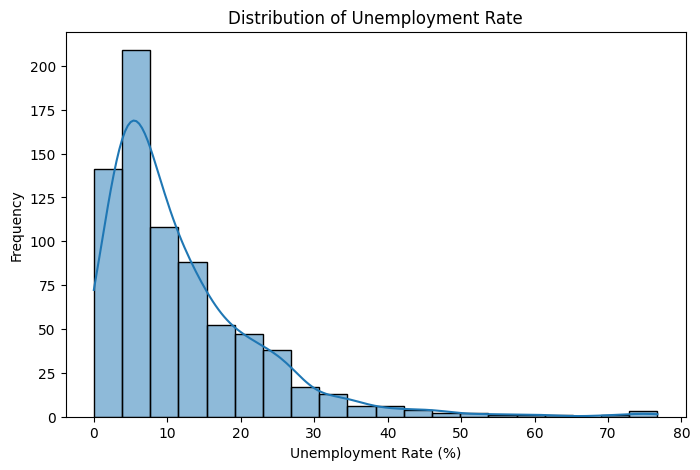

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Estimated Unemployment Rate (%)'],
    bins=20,
    kde=True
)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
state_unemployment = df.groupby('Region')[
    'Estimated Unemployment Rate (%)'
].mean().sort_values(ascending=False)

print(state_unemployment)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


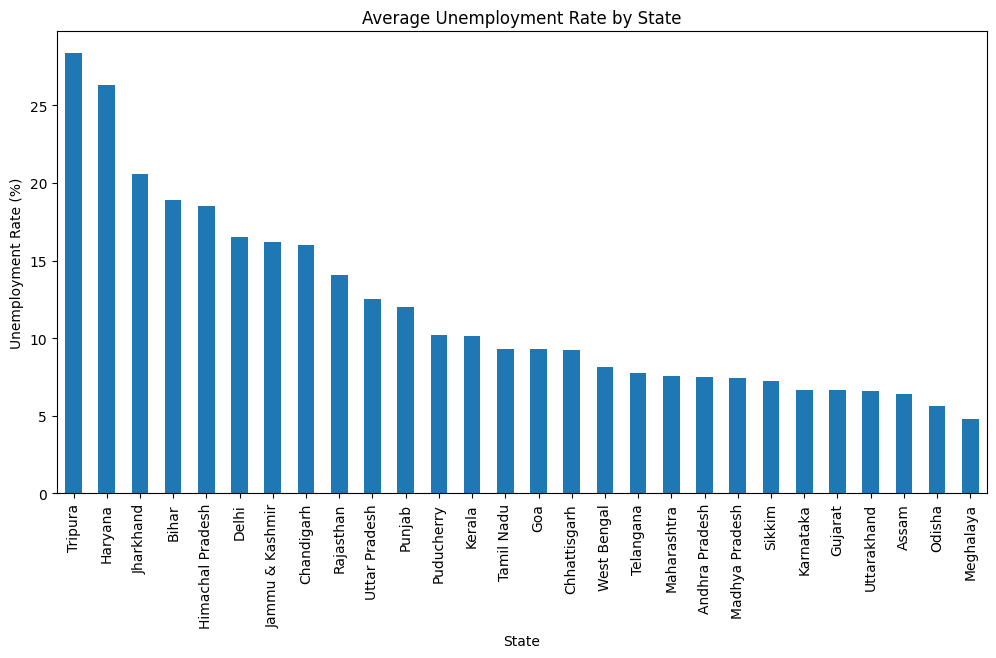

In [ ]:
plt.figure(figsize=(12,6))

state_unemployment.plot(kind='bar')

plt.title("Average Unemployment Rate by State")
plt.xlabel("State")
plt.ylabel("Unemployment Rate (%)")

plt.show()

In [ ]:
covid_data = df[df['Date'] >= '2020-03-01']
pre_covid = df[df['Date'] < '2020-03-01']

print("Pre-COVID Average:",
      pre_covid['Estimated Unemployment Rate (%)'].mean())

print("COVID Period Average:",
      covid_data['Estimated Unemployment Rate (%)'].mean())

Pre-COVID Average: 11.787945945945946
COVID Period Average: nan


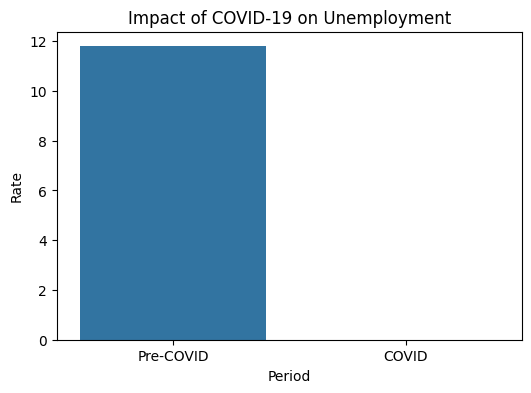

In [ ]:
comparison = pd.DataFrame({
    'Period':['Pre-COVID','COVID'],
    'Rate':[
        pre_covid['Estimated Unemployment Rate (%)'].mean(),
        covid_data['Estimated Unemployment Rate (%)'].mean()
    ]
})

plt.figure(figsize=(6,4))

sns.barplot(
    x='Period',
    y='Rate',
    data=comparison
)

plt.title("Impact of COVID-19 on Unemployment")

plt.show()

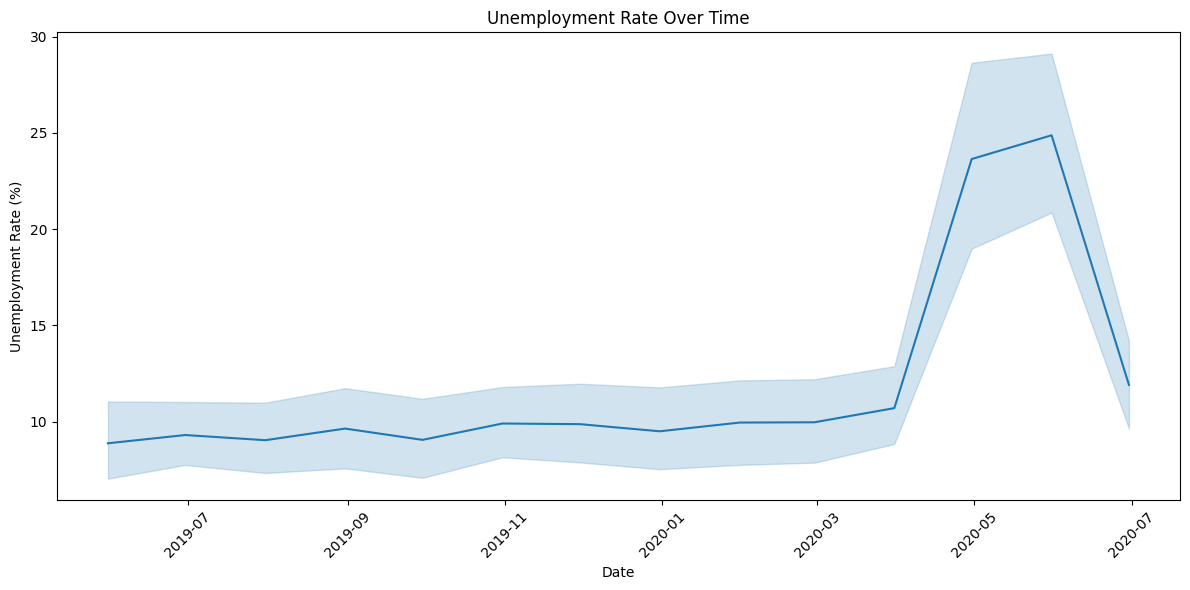

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df = df.sort_values('Date')

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x='Date',
    y='Estimated Unemployment Rate (%)'
)

plt.title('Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

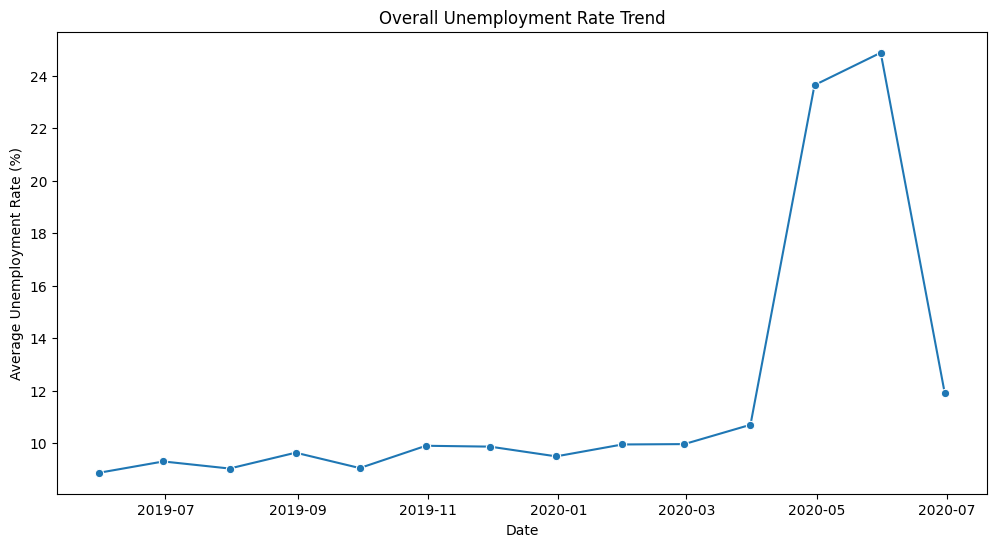

In [ ]:
overall_trend = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(12,6))

sns.lineplot(
    data=overall_trend,
    x='Date',
    y='Estimated Unemployment Rate (%)',
    marker='o'
)

plt.title('Overall Unemployment Rate Trend')
plt.xlabel('Date')
plt.ylabel('Average Unemployment Rate (%)')

plt.show()

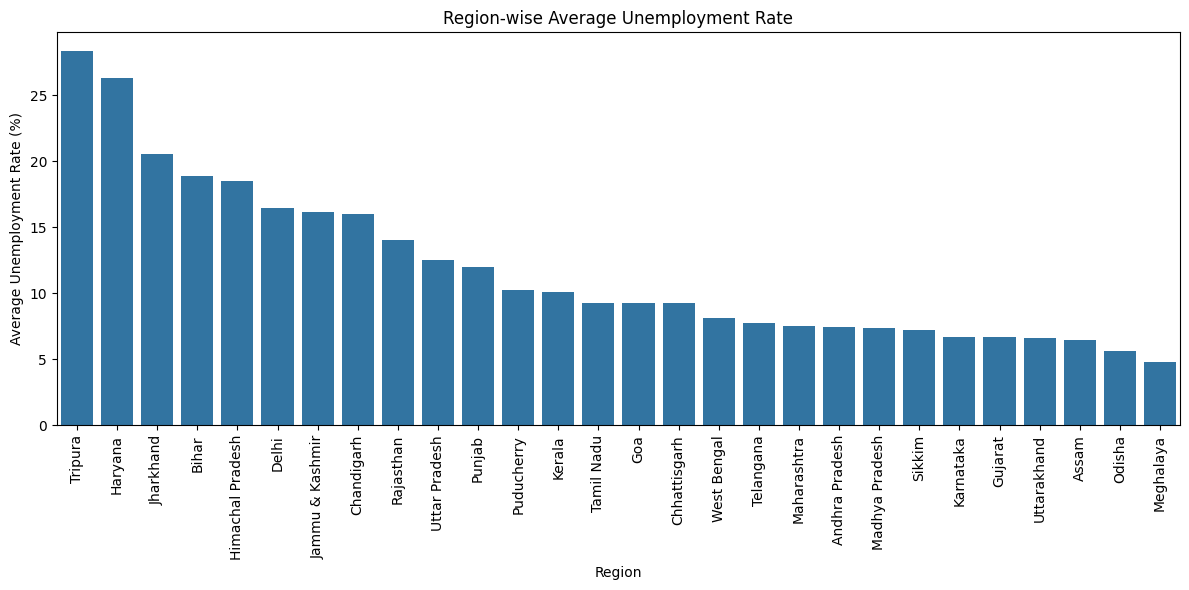

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average unemployment rate by region
region_rate = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

# Sort values
region_rate = region_rate.sort_values(ascending=False)

# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    x=region_rate.index,
    y=region_rate.values
)

plt.title('Region-wise Average Unemployment Rate')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Check result
print(df['Date'].head())

0     2019-05-31
290   2019-05-31
276   2019-05-31
257   2019-05-31
243   2019-05-31
Name: Date, dtype: datetime64[ns]


In [ ]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

print(df[['Date', 'Year', 'Month', 'Day']].head())

          Date  Year  Month  Day
0   2019-05-31  2019      5   31
290 2019-05-31  2019      5   31
276 2019-05-31  2019      5   31
257 2019-05-31  2019      5   31
243 2019-05-31  2019      5   31


In [ ]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Filter only 2020 data
covid_year = df[df['Date'].dt.year == 2020]

print(covid_year.head())

               Region       Date Frequency  Estimated Unemployment Rate (%)  \
116  Himachal Pradesh 2020-01-31   Monthly                            16.67   
312           Tripura 2020-01-31   Monthly                            31.91   
734       Uttarakhand 2020-01-31   Monthly                             8.92   
527         Jharkhand 2020-01-31   Monthly                            22.96   
225            Odisha 2020-01-31   Monthly                             1.81   

     Estimated Employed  Estimated Labour Participation Rate (%)   Area  Year  \
116           2041035.0                                    45.11  Rural  2020   
312           1057975.0                                    68.61  Rural  2020   
734            725253.0                                    27.55  Urban  2020   
527           2329293.0                                    44.33  Urban  2020   
225          11182128.0                                    39.09  Rural  2020   

     Month  Day  
116      1   31  
31

In [ ]:
avg_covid_rate = covid_year['Estimated Unemployment Rate (%)'].mean()

print("Average Unemployment Rate in 2020:", avg_covid_rate)

Average Unemployment Rate in 2020: 15.10158064516129


In [ ]:
print("="*50)
print("      UNEMPLOYMENT ANALYSIS PROJECT")
print("="*50)

# Dataset Information
print("\nDataset Shape:", df.shape)

# Average unemployment rate
avg_rate = df['Estimated Unemployment Rate (%)'].mean()
print("\nAverage Unemployment Rate:", round(avg_rate, 2))

# Highest unemployment region
highest_region = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().idxmax()
highest_rate = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().max()

print("\nHighest Unemployment Region:", highest_region)
print("Average Rate:", round(highest_rate, 2))

# Lowest unemployment region
lowest_region = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().idxmin()
lowest_rate = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().min()

print("\nLowest Unemployment Region:", lowest_region)
print("Average Rate:", round(lowest_rate, 2))

print("\n========== SAMPLE RECORDS ==========\n")
print(df[['Region','Estimated Unemployment Rate (%)']].head(10))

print("\n========== PROJECT INSIGHTS ==========\n")

print("1. Unemployment rates vary significantly across regions.")
print("2. COVID-19 caused a sharp rise in unemployment during 2020.")
print("3. Some regions consistently recorded higher unemployment rates.")
print("4. Seasonal variations can be observed in monthly trends.")
print("5. Data visualization helps identify employment patterns effectively.")

print("\n========== CONCLUSION ==========\n")

print("• COVID-19 had a significant impact on unemployment levels.")
print("• Regional disparities exist in employment opportunities.")
print("• Policymakers can use these insights for targeted interventions.")
print("• Trend analysis helps understand economic recovery patterns.")

print("\n========== PROJECT COMPLETED ==========")
print("Successfully performed Unemployment Analysis using Python,")
print("including data cleaning, visualization, COVID-19 impact analysis,")
print("regional analysis, and trend identification.")

      UNEMPLOYMENT ANALYSIS PROJECT

Dataset Shape: (740, 10)

Average Unemployment Rate: 11.79

Highest Unemployment Region: Tripura
Average Rate: 28.35

Lowest Unemployment Region: Meghalaya
Average Rate: 4.8

========== SAMPLE RECORDS ==========

             Region  Estimated Unemployment Rate (%)
0    Andhra Pradesh                             3.65
290       Telangana                             2.23
276      Tamil Nadu                             0.97
257       Rajasthan                             4.03
243          Punjab                             9.17
670      Tamil Nadu                             0.89
231      Puducherry                             0.00
217          Odisha                             4.17
203       Meghalaya                             3.16
684       Telangana                             1.52

========== PROJECT INSIGHTS ==========

1. Unemployment rates vary significantly across regions.
2. COVID-19 caused a sharp rise in unemployment during 2020.
3. Some 